In [20]:
from ocelot import *
from ocelot.cpbd.elements import *
from ocelot.gui.accelerator import *
import matplotlib.pyplot as plt

# define parameters of laser system
wavelength = 266e-9 # [m]
lens_length = 1e-6 # [m]
Radius_of_lens1 = 428.5e-3 # [m]
Radius_of_lens2 = -237.8e-3 # [m]
Radius_of_lens3 = 238e-3 # [m]
n = 1.49968

def f(R):
    return R / (n - 1)

d0 = Drift(l=1.3)
d1 = Drift(l=4.9)
d2 = Drift(l=0.822)
d3 = Drift(l=0.781)

len0 = Quadrupole(l=lens_length, k1=1/f(Radius_of_lens1)/lens_length)
len1 = Quadrupole(l=lens_length, k1=1/f(Radius_of_lens2)/lens_length)
len2 = Quadrupole(l=lens_length, k1=1/f(Radius_of_lens3)/lens_length)

laser = (d0, len0, d1, len1, d2, len2, d3)
lat_laser = MagneticLattice(laser)

# transfer laser parameter to electron beam parameter
M_square = 1.6
emittance = M_square * wavelength / np.pi / 4
sigma_0 = 50e-6 # [m]
beta_0 = sigma_0**2 / emittance

# define parameters of electron beam
beam = Beam()
beam.beta_x = beta_0 # [m]
beam.beta_y = beta_0 # [m]
beam.emit_x = emittance # [m rad]
beam.emit_y = emittance # [m rad]

对于光学系统，在薄透镜近似下传输矩阵可以写作
$\begin{pmatrix}
1 & 0 \\
-\frac{1}{f} & 1
\end{pmatrix}$；同时对于束流光学，薄透镜近似下的四级铁可以传输矩阵可以写为
$\begin{pmatrix}
1 & 0 \\
-KL & 1
\end{pmatrix}$。这两个矩阵可以直接等同，$\frac{1}{f} = K_1 * L \quad \Rightarrow \quad K_1 = \frac{1}{fL}$。


对于激光系统所说的$M^2$与束流发射度emittance之间的关系为$BPP = M^2\frac{\lambda}{\pi} = \frac{2M^2}{k} = 4\sigma_0 \sigma_0' = 4\varepsilon$。其中$\lambda$是激光的波长，*k*是波数。
由这个公式就可以将激光的$M^2$转换为束流的emittance参数。

$\beta$函数与光束尺寸的关系可以写作$\beta(z) = \frac{\sigma^2(z)}{\varepsilon}$。对于此激光系统，使用了pinhole来控制激光光束尺寸至均匀的圆形，所以$\sigma = Diameter / 4 = 200/4 = 50 mm$。

束流尺寸计算公式为：$\sigma_x = \sqrt{\frac{2m+1}{2k}\beta}=\sqrt{\varepsilon_x\beta}$，y和x公式一样。

激光是轴对称的，所以只需要计算x方向就行。

参考文献：Floettmann, K. (2020). Equivalence of Gouy and Courant-Snyder phase. Physical Review A, 102(3), 033507.

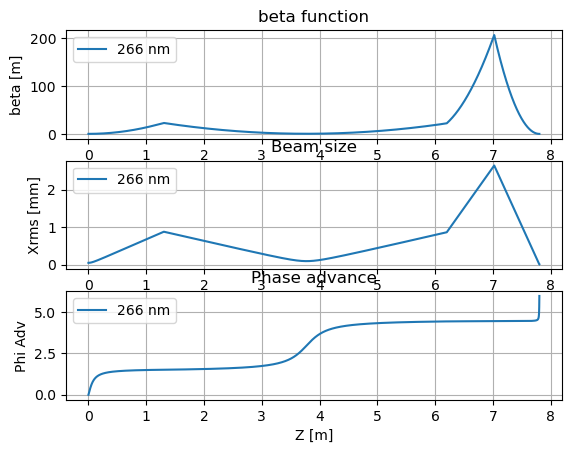

In [24]:
# calculate twiss parameters
tw0 = Twiss(beam)
tws = twiss(lat_laser, tw0, nPoints=10000)
beta = [p.beta_x for p in tws]
pos = [p.s for p in tws]
emit = [p.emit_x for p in tws]
Xrms = np.sqrt(np.array(emit) * np.array(beta))
mu = [p.mux for p in tws]

# plot
plt.subplot(3,1,1)
plt.plot(pos, beta, label="266 nm")
plt.title("beta function")
plt.xlabel("Z [m]")
plt.ylabel("beta [m]")
plt.grid()
plt.legend()

plt.subplot(3,1,2)
plt.plot(pos, Xrms*1e3, label="266 nm")
plt.title("Beam size")
plt.xlabel("Z [m]")
plt.ylabel("Xrms [mm]")
plt.grid()
plt.legend()

plt.subplot(3,1,3)
plt.plot(pos, mu, label="266 nm")
plt.title("Phase advance")
plt.xlabel("Z [m]")
plt.ylabel("Phi Adv")
plt.grid()
plt.legend()

plt.show()
